# Diabetes Classification with Ensemble Models

- **Author:** Abdellah Boudlal
- **Date:** 2026-07
- **Dataset:** `data/raw/diabetes.csv`
- **Problem type:** Supervised classification
- **Goal:** Compare a single decision tree with Random Forest, Gradient Boosting, and Extra Trees for predicting diabetes status.

This is the Phase 5 custom project. It applies the ensemble-modeling workflow to a new dataset while keeping the same professional sequence: setup, load, prepare, split, model, evaluate, visualize, and summarize.

> **Important:** This educational analysis is not a medical diagnostic tool.


## 1. Project Setup

This section:

- locates the repository automatically;
- configures logging to `project.log`;
- creates output folders;
- imports all required packages.

No path changes are required when the notebook is stored in the repository's `notebooks/` folder.


In [4]:
from __future__ import annotations

from importlib.metadata import version
import logging
from pathlib import Path
import platform
from typing import Final

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Find the repository root from the current working directory.
CURRENT_DIR: Final[Path] = Path.cwd().resolve()
PROJECT_ROOT: Path | None = None

for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "data" / "raw" / "diabetes.csv").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find data/raw/diabetes.csv. "
        "Place this notebook in the repository's notebooks folder "
        "and run it with the local .venv kernel."
    )

DATA_PATH: Final[Path] = PROJECT_ROOT / "data" / "raw" / "diabetes.csv"
DOCS_IMAGES_DIR: Final[Path] = PROJECT_ROOT / "docs" / "images"
PROCESSED_DIR: Final[Path] = PROJECT_ROOT / "data" / "processed"
LOG_PATH: Final[Path] = PROJECT_ROOT / "project.log"

DOCS_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


# Configure a notebook logger that appends to the shared project.log file.
LOG = logging.getLogger("M05_PHASE5")
LOG.setLevel(logging.DEBUG)
LOG.handlers.clear()
LOG.propagate = False

formatter = logging.Formatter("%(asctime)s | %(levelname)s | M05-PHASE5 | %(message)s")

file_handler = logging.FileHandler(LOG_PATH, mode="a", encoding="utf-8")
file_handler.setFormatter(formatter)
file_handler.setLevel(logging.DEBUG)

stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
stream_handler.setLevel(logging.INFO)

LOG.addHandler(file_handler)
LOG.addHandler(stream_handler)

LOG.info("=== PHASE 5 RUN START ===")
LOG.info("project_root=%s", PROJECT_ROOT)
LOG.info("data_path=%s", DATA_PATH)
LOG.info("python=%s", platform.python_version())
LOG.info("pandas=%s", version("pandas"))
LOG.info("numpy=%s", version("numpy"))
LOG.info("scikit-learn=%s", version("scikit-learn"))
LOG.info("seaborn=%s", version("seaborn"))
LOG.info("matplotlib=%s", version("matplotlib"))

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_context("notebook")

2026-07-31 20:44:31,397 | INFO | M05-PHASE5 | === PHASE 5 RUN START ===
2026-07-31 20:44:31,399 | INFO | M05-PHASE5 | project_root=C:\Repos\ml-05-ensembles
2026-07-31 20:44:31,400 | INFO | M05-PHASE5 | data_path=C:\Repos\ml-05-ensembles\data\raw\diabetes.csv
2026-07-31 20:44:31,402 | INFO | M05-PHASE5 | python=3.14.2
2026-07-31 20:44:31,408 | INFO | M05-PHASE5 | pandas=3.0.5
2026-07-31 20:44:31,412 | INFO | M05-PHASE5 | numpy=2.5.1
2026-07-31 20:44:31,416 | INFO | M05-PHASE5 | scikit-learn=1.9.0
2026-07-31 20:44:31,420 | INFO | M05-PHASE5 | seaborn=0.13.2
2026-07-31 20:44:31,431 | INFO | M05-PHASE5 | matplotlib=3.11.1


## 2. Load and Inspect the Dataset

The local CSV supplied with the project is loaded directly. The notebook detects the target column from common diabetes-label names, reports the data shape, and displays a preview.


In [5]:
df: pd.DataFrame = pd.read_csv(DATA_PATH)

LOG.info("Loaded diabetes dataset: %d rows, %d columns", df.shape[0], df.shape[1])
LOG.info("Columns: %s", df.columns.tolist())

TARGET_CANDIDATES: Final[list[str]] = [
    "Diabetes_binary",
    "Diabetes_012",
    "Outcome",
    "Diabetes",
    "diabetes",
    "Diabetic",
    "Diagnosis",
]

TARGET_COL: str | None = next(
    (column for column in TARGET_CANDIDATES if column in df.columns),
    None,
)

if TARGET_COL is None:
    raise KeyError(
        "No supported target column was found. "
        f"Available columns are: {df.columns.tolist()}"
    )

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Detected target: {TARGET_COL}")
print("\nTarget distribution:")
display(df[TARGET_COL].value_counts(dropna=False).rename("count").to_frame())
display(df.head())

2026-07-31 20:44:31,690 | INFO | M05-PHASE5 | Loaded diabetes dataset: 70692 rows, 22 columns
2026-07-31 20:44:31,691 | INFO | M05-PHASE5 | Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


Dataset shape: 70,692 rows × 22 columns
Detected target: Diabetes_binary

Target distribution:


,count
Diabetes_binary,
0.0,35346
1.0,35346


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## 3. Prepare Features and Target

The notebook:

- removes rows with a missing target;
- separates the target from the predictor columns;
- converts categorical predictors with one-hot encoding if needed;
- replaces infinite values;
- fills remaining numeric missing values with column medians;
- encodes a text target only when necessary.

The original raw CSV is not modified.


In [6]:
model_df: pd.DataFrame = df.dropna(subset=[TARGET_COL]).copy()

y_original: pd.Series = model_df[TARGET_COL].copy()
X_raw: pd.DataFrame = model_df.drop(columns=[TARGET_COL]).copy()

# Convert any categorical feature columns to numeric indicator columns.
categorical_columns: list[str] = X_raw.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

if categorical_columns:
    LOG.info("One-hot encoding categorical columns: %s", categorical_columns)
    X: pd.DataFrame = pd.get_dummies(
        X_raw,
        columns=categorical_columns,
        drop_first=False,
        dtype=float,
    )
else:
    X = X_raw.copy()

X.columns = X.columns.astype(str)
X = X.replace([np.inf, -np.inf], np.nan)

# Fill numeric missing values without deleting otherwise usable rows.
numeric_medians: pd.Series = X.median(numeric_only=True)
X = X.fillna(numeric_medians)

# A final fallback handles any all-missing columns.
if X.isna().any().any():
    X = X.fillna(0)

label_encoder: LabelEncoder | None = None
class_mapping: dict[int, str] | None = None

if not pd.api.types.is_numeric_dtype(y_original):
    label_encoder = LabelEncoder()
    y = pd.Series(
        label_encoder.fit_transform(y_original.astype(str)),
        index=y_original.index,
        name=TARGET_COL,
    )
    class_mapping = {
        int(index): str(label) for index, label in enumerate(label_encoder.classes_)
    }
else:
    y = y_original.copy()

class_counts: pd.Series = y.value_counts().sort_index()

if class_counts.size < 2:
    raise ValueError("The target must contain at least two classes.")

if class_counts.min() < 2:
    raise ValueError(
        "Every target class must have at least two instances "
        "for a stratified train-test split."
    )

LOG.info("Prepared modeling data: %d rows, %d features", X.shape[0], X.shape[1])
LOG.info("Target classes: %s", class_counts.to_dict())
LOG.info("Missing feature values after preparation: %d", int(X.isna().sum().sum()))

print(f"Modeling rows: {X.shape[0]:,}")
print(f"Predictor columns after preparation: {X.shape[1]}")
print(f"Target classes: {class_counts.to_dict()}")
if class_mapping is not None:
    print(f"Encoded class mapping: {class_mapping}")

2026-07-31 20:44:31,865 | INFO | M05-PHASE5 | Prepared modeling data: 70692 rows, 21 features
2026-07-31 20:44:31,867 | INFO | M05-PHASE5 | Target classes: {0.0: 35346, 1.0: 35346}
2026-07-31 20:44:31,872 | INFO | M05-PHASE5 | Missing feature values after preparation: 0


Modeling rows: 70,692
Predictor columns after preparation: 21
Target classes: {0.0: 35346, 1.0: 35346}


## 4. Visualize the Target Distribution

The class-distribution chart helps determine whether ordinary accuracy is sufficient or whether balanced metrics should also be considered.


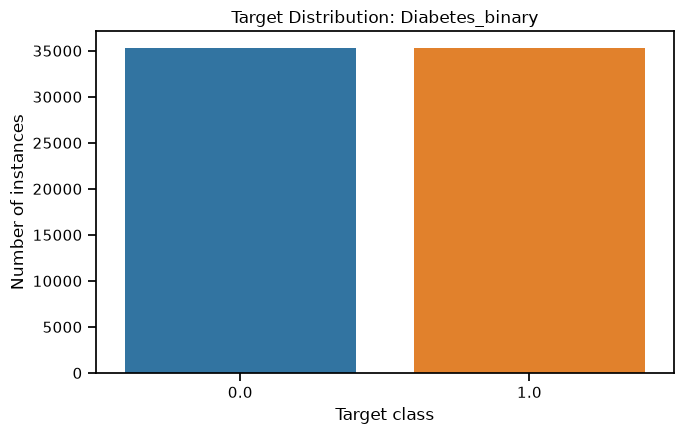

2026-07-31 20:44:32,484 | INFO | M05-PHASE5 | Saved target distribution chart: C:\Repos\ml-05-ensembles\docs\images\phase5_target_distribution.png


In [7]:
target_counts_plot = (
    y.astype(str)
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
    .sort_values("class")
)

plt.figure(figsize=(7, 4.5))
sns.barplot(
    data=target_counts_plot,
    x="class",
    y="count",
    hue="class",
    legend=False,
)
plt.title(f"Target Distribution: {TARGET_COL}")
plt.xlabel("Target class")
plt.ylabel("Number of instances")
plt.tight_layout()

target_figure_path = DOCS_IMAGES_DIR / "phase5_target_distribution.png"
plt.savefig(target_figure_path, dpi=200, bbox_inches="tight")
plt.show()

LOG.info("Saved target distribution chart: %s", target_figure_path)

## 5. Create a Stratified Training and Test Split

Twenty percent of the data is held out for final evaluation. Stratification preserves the target-class proportions in both subsets.


In [8]:
RANDOM_STATE: Final[int] = 42
TEST_SIZE: Final[float] = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

LOG.info("Training instances: %d", len(X_train))
LOG.info("Testing instances: %d", len(X_test))

print(f"Training instances: {len(X_train):,}")
print(f"Testing instances: {len(X_test):,}")

2026-07-31 20:44:32,618 | INFO | M05-PHASE5 | Training instances: 56553
2026-07-31 20:44:32,619 | INFO | M05-PHASE5 | Testing instances: 14139


Training instances: 56,553
Testing instances: 14,139


## 6. Train One Baseline and Three Ensemble Models

The single decision tree is the baseline. Random Forest, Gradient Boosting, and Extra Trees are ensemble methods. Every model receives the same training data.


In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

for model_name, model in models.items():
    LOG.info("Training model: %s", model_name)
    model.fit(X_train, y_train)
    LOG.info("Finished model: %s", model_name)

print("Successfully trained:")
for model_name in models:
    print(f"- {model_name}")

2026-07-31 20:44:32,636 | INFO | M05-PHASE5 | Training model: Decision Tree
2026-07-31 20:44:32,791 | INFO | M05-PHASE5 | Finished model: Decision Tree
2026-07-31 20:44:32,792 | INFO | M05-PHASE5 | Training model: Random Forest
2026-07-31 20:44:38,367 | INFO | M05-PHASE5 | Finished model: Random Forest
2026-07-31 20:44:38,369 | INFO | M05-PHASE5 | Training model: Gradient Boosting
2026-07-31 20:44:45,937 | INFO | M05-PHASE5 | Finished model: Gradient Boosting
2026-07-31 20:44:45,938 | INFO | M05-PHASE5 | Training model: Extra Trees
2026-07-31 20:44:53,676 | INFO | M05-PHASE5 | Finished model: Extra Trees


Successfully trained:
- Decision Tree
- Random Forest
- Gradient Boosting
- Extra Trees


## 7. Evaluate the Models

The models are evaluated on the same held-out test set using:

- accuracy;
- balanced accuracy;
- precision;
- recall;
- F1 score;
- ROC AUC when probability estimates are available.

The best model is selected primarily by held-out accuracy, with F1 score used to break a tie.


In [10]:
is_binary: bool = y.nunique() == 2
metric_average: str = "binary" if is_binary else "weighted"

evaluation_rows: list[dict[str, float | str]] = []
predictions_by_model: dict[str, np.ndarray] = {}
reports_by_model: dict[str, dict] = {}

for model_name, model in models.items():
    predictions = model.predict(X_test)
    predictions_by_model[model_name] = predictions

    accuracy = float(accuracy_score(y_test, predictions))
    balanced_accuracy = float(balanced_accuracy_score(y_test, predictions))
    precision = float(
        precision_score(
            y_test,
            predictions,
            average=metric_average,
            zero_division=0,
        )
    )
    recall = float(
        recall_score(
            y_test,
            predictions,
            average=metric_average,
            zero_division=0,
        )
    )
    f1 = float(
        f1_score(
            y_test,
            predictions,
            average=metric_average,
            zero_division=0,
        )
    )

    roc_auc = np.nan
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)
        try:
            if is_binary:
                roc_auc = float(roc_auc_score(y_test, probabilities[:, 1]))
            else:
                roc_auc = float(
                    roc_auc_score(
                        y_test,
                        probabilities,
                        multi_class="ovr",
                        average="weighted",
                    )
                )
        except ValueError:
            roc_auc = np.nan

    evaluation_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": roc_auc,
        }
    )

    reports_by_model[model_name] = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0,
    )

    LOG.info(
        "%s | accuracy=%.4f | balanced_accuracy=%.4f | "
        "precision=%.4f | recall=%.4f | f1=%.4f | roc_auc=%s",
        model_name,
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1,
        "N/A" if np.isnan(roc_auc) else f"{roc_auc:.4f}",
    )

results_df = (
    pd.DataFrame(evaluation_rows)
    .sort_values(["accuracy", "f1"], ascending=False)
    .reset_index(drop=True)
)

best_model_name: str = str(results_df.loc[0, "model"])
best_model = models[best_model_name]
best_predictions = predictions_by_model[best_model_name]

results_output_path = PROCESSED_DIR / "phase5_model_results.csv"
results_df.to_csv(results_output_path, index=False)

LOG.info("Best model: %s", best_model_name)
LOG.info("Saved model results: %s", results_output_path)

display(
    results_df.style.format(
        {
            "accuracy": "{:.3f}",
            "balanced_accuracy": "{:.3f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "roc_auc": "{:.3f}",
        },
        na_rep="N/A",
    )
)

2026-07-31 20:44:53,836 | INFO | M05-PHASE5 | Decision Tree | accuracy=0.7306 | balanced_accuracy=0.7306 | precision=0.7119 | recall=0.7748 | f1=0.7420 | roc_auc=0.8058
2026-07-31 20:44:54,706 | INFO | M05-PHASE5 | Random Forest | accuracy=0.7360 | balanced_accuracy=0.7361 | precision=0.7192 | recall=0.7745 | f1=0.7458 | roc_auc=0.8115
2026-07-31 20:44:54,878 | INFO | M05-PHASE5 | Gradient Boosting | accuracy=0.7539 | balanced_accuracy=0.7539 | precision=0.7337 | recall=0.7973 | f1=0.7642 | roc_auc=0.8296
2026-07-31 20:44:55,781 | INFO | M05-PHASE5 | Extra Trees | accuracy=0.7235 | balanced_accuracy=0.7235 | precision=0.7075 | recall=0.7621 | f1=0.7338 | roc_auc=0.7932
2026-07-31 20:44:55,799 | INFO | M05-PHASE5 | Best model: Gradient Boosting
2026-07-31 20:44:55,801 | INFO | M05-PHASE5 | Saved model results: C:\Repos\ml-05-ensembles\data\processed\phase5_model_results.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.754,0.754,0.734,0.797,0.764,0.830
1,Random Forest,0.736,0.736,0.719,0.775,0.746,0.812
2,Decision Tree,0.731,0.731,0.712,0.775,0.742,0.806
3,Extra Trees,0.724,0.724,0.708,0.762,0.734,0.793


## 8. Compare Model Performance

The comparison chart displays held-out accuracy and balanced accuracy for all four models.


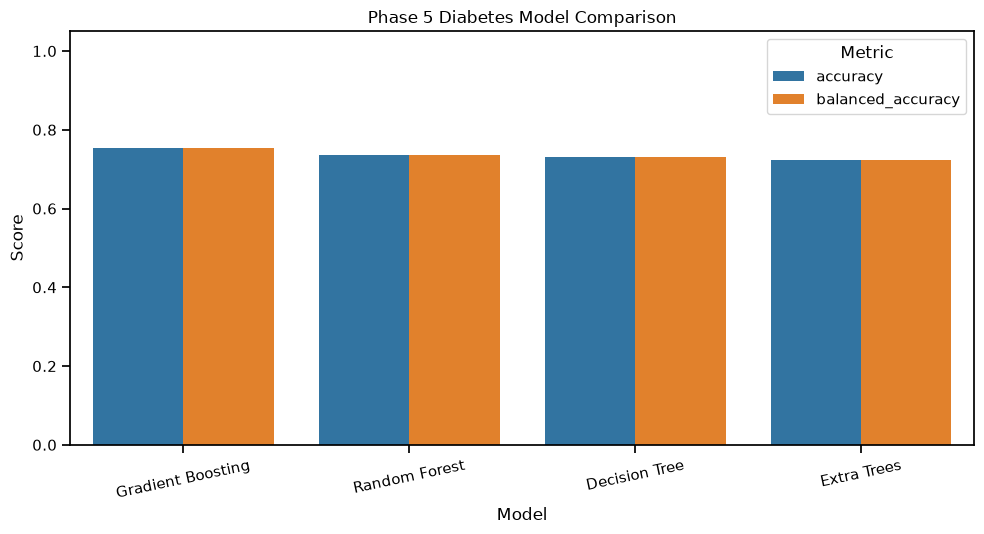

2026-07-31 20:44:56,957 | INFO | M05-PHASE5 | Saved model comparison chart: C:\Repos\ml-05-ensembles\docs\images\phase5_model_comparison.png


In [11]:
comparison_long = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "balanced_accuracy"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5.5))
sns.barplot(
    data=comparison_long,
    x="model",
    y="score",
    hue="metric",
)
plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Phase 5 Diabetes Model Comparison")
plt.xticks(rotation=12)
plt.legend(title="Metric")
plt.tight_layout()

comparison_figure_path = DOCS_IMAGES_DIR / "phase5_model_comparison.png"
plt.savefig(comparison_figure_path, dpi=200, bbox_inches="tight")
plt.show()

LOG.info("Saved model comparison chart: %s", comparison_figure_path)

## 9. Confusion Matrix for the Best Model

The confusion matrix shows where the selected model classified test instances correctly and incorrectly.


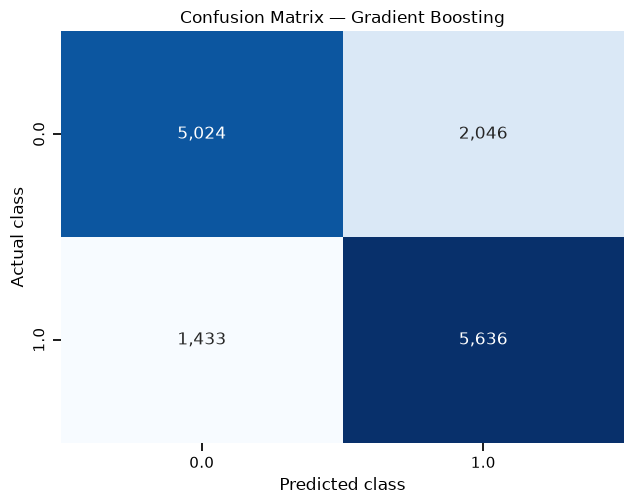

2026-07-31 20:44:57,458 | INFO | M05-PHASE5 | Saved confusion matrix: C:\Repos\ml-05-ensembles\docs\images\phase5_confusion_matrix.png


,precision,recall,f1-score,support
0.0,0.778070,0.710608,0.742811,7070.000000
1.0,0.733663,0.797284,0.764152,7069.000000
accuracy,0.753943,0.753943,0.753943,0.753943
macro avg,0.755867,0.753946,0.753481,14139.000000
weighted avg,0.755868,0.753943,0.753480,14139.000000


In [12]:
labels = np.sort(y.unique())
matrix = confusion_matrix(y_test, best_predictions, labels=labels)

plt.figure(figsize=(6.5, 5.2))
sns.heatmap(
    matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()

confusion_figure_path = DOCS_IMAGES_DIR / "phase5_confusion_matrix.png"
plt.savefig(confusion_figure_path, dpi=200, bbox_inches="tight")
plt.show()

LOG.info("Saved confusion matrix: %s", confusion_figure_path)

report_df = pd.DataFrame(reports_by_model[best_model_name]).transpose()
display(report_df)

## 10. Feature Importance

Tree-based models provide feature-importance values. The chart displays the most influential predictors used by the best-performing model.


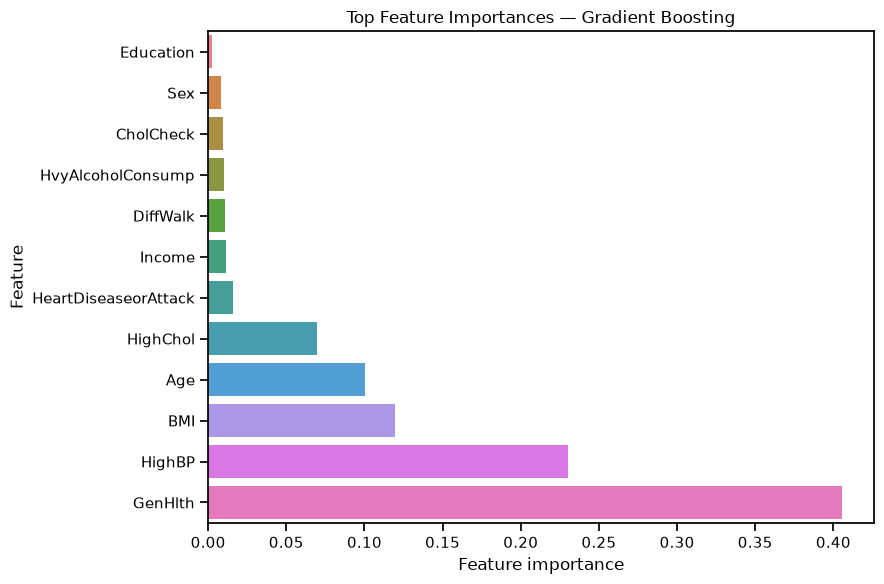

2026-07-31 20:44:58,422 | INFO | M05-PHASE5 | Saved feature importance chart: C:\Repos\ml-05-ensembles\docs\images\phase5_feature_importance.png
2026-07-31 20:44:58,423 | INFO | M05-PHASE5 | Saved feature importance data: C:\Repos\ml-05-ensembles\data\processed\phase5_feature_importance.csv


,feature,importance
0,GenHlth,0.4057
1,HighBP,0.2302
2,BMI,0.1193
3,Age,0.1003
4,HighChol,0.0696
5,HeartDiseaseorAttack,0.0160
6,Income,0.0116
7,DiffWalk,0.0109
8,HvyAlcoholConsump,0.0103
9,CholCheck,0.0095


In [13]:
if not hasattr(best_model, "feature_importances_"):
    raise AttributeError(f"{best_model_name} does not provide feature_importances_.")

importance_df = (
    pd.DataFrame(
        {
            "feature": X.columns,
            "importance": best_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_feature_count = min(12, len(importance_df))
top_importance_df = importance_df.head(top_feature_count).sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_importance_df,
    x="importance",
    y="feature",
    hue="feature",
    legend=False,
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title(f"Top Feature Importances — {best_model_name}")
plt.tight_layout()

importance_figure_path = DOCS_IMAGES_DIR / "phase5_feature_importance.png"
plt.savefig(importance_figure_path, dpi=200, bbox_inches="tight")
plt.show()

importance_output_path = PROCESSED_DIR / "phase5_feature_importance.csv"
importance_df.to_csv(importance_output_path, index=False)

LOG.info("Saved feature importance chart: %s", importance_figure_path)
LOG.info("Saved feature importance data: %s", importance_output_path)

display(importance_df.head(12).style.format({"importance": "{:.4f}"}))

## 11. Automatically Generated Analyst Narrative

This final cell produces a complete results narrative from the actual outputs. No accuracy values or model names need to be entered manually.


In [ ]:
best_row = results_df.iloc[0]
top_feature_name = str(importance_df.iloc[0]["feature"])
top_feature_value = float(importance_df.iloc[0]["importance"])

balance_ratio = float(class_counts.min() / class_counts.max())
balance_description = (
    "relatively balanced"
    if balance_ratio >= 0.80
    else "moderately imbalanced"
    if balance_ratio >= 0.50
    else "imbalanced"
)

roc_auc_text = (
    "N/A" if pd.isna(best_row["roc_auc"]) else f"{float(best_row['roc_auc']):.3f}"
)

analyst_narrative = f"""
## Phase 5 Results and Analyst Insights

### Basis and Data

This custom project used the local `data/raw/diabetes.csv` dataset. After removing rows with a missing target, the analysis used **{X.shape[0]:,} instances** and **{X.shape[1]} prepared predictor columns**. The detected target was **`{TARGET_COL}`**, with **{y.nunique()} classes**. The target distribution was {balance_description}.

### Modeling Approach

This was a supervised classification problem because the dataset included a known target label. I used a stratified 80/20 train-test split and compared one single decision tree with three ensemble models: Random Forest, Gradient Boosting, and Extra Trees. Every model was trained on the same training data and evaluated on the same held-out test data.

### Evaluation and Results

The best model was **{best_model_name}**. Its held-out results were:

- Accuracy: **{float(best_row['accuracy']):.3f}**
- Balanced accuracy: **{float(best_row['balanced_accuracy']):.3f}**
- Precision: **{float(best_row['precision']):.3f}**
- Recall: **{float(best_row['recall']):.3f}**
- F1 score: **{float(best_row['f1']):.3f}**
- ROC AUC: **{roc_auc_text}**

The most influential feature for the selected model was **`{top_feature_name}`**, with an importance score of **{top_feature_value:.3f}**. The confusion matrix provides additional detail about correct and incorrect classifications for each target class.

### Analyst Judgment

The ensemble workflow made it possible to compare several tree-based approaches under the same conditions. The selected model produced the strongest held-out accuracy for this split. However, a single train-test split does not prove that the same performance will occur on all future data. Cross-validation, hyperparameter tuning, fairness analysis, and validation on an independent dataset would strengthen the conclusions.

### Summary

I successfully adapted the original Penguins ensemble example to a diabetes-classification problem. The notebook loads and prepares a new CSV dataset, trains four models, evaluates them with multiple classification metrics, creates three documentation-ready charts, exports model results and feature importance data, and records the workflow in `project.log`.

This project is an educational machine-learning exercise and must not be used as a medical diagnosis system.
"""

display(Markdown(analyst_narrative))

LOG.info("========================")
LOG.info("PHASE 5 SUMMARY")
LOG.info("========================")
LOG.info("Dataset rows: %d", X.shape[0])
LOG.info("Prepared features: %d", X.shape[1])
LOG.info("Target: %s", TARGET_COL)
LOG.info("Best model: %s", best_model_name)
LOG.info("Best accuracy: %.4f", float(best_row["accuracy"]))
LOG.info("Best balanced accuracy: %.4f", float(best_row["balanced_accuracy"]))
LOG.info("Best F1: %.4f", float(best_row["f1"]))
LOG.info("Top feature: %s (%.4f)", top_feature_name, top_feature_value)
LOG.info("PHASE 5 EXECUTED SUCCESSFULLY")
LOG.info("========================")

print("Generated files:")
print(f"- {comparison_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {confusion_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {importance_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {target_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {results_output_path.relative_to(PROJECT_ROOT)}")
print(f"- {importance_output_path.relative_to(PROJECT_ROOT)}")
print("\nPHASE 5 EXECUTED SUCCESSFULLY")


## Phase 5 Results and Analyst Insights

### Basis and Data

This custom project used the local `data/raw/diabetes.csv` dataset. After removing rows with a missing target, the analysis used **70,692 instances** and **21 prepared predictor columns**. The detected target was **`Diabetes_binary`**, with **2 classes**. The target distribution was relatively balanced.

### Modeling Approach

This was a supervised classification problem because the dataset included a known target label. I used a stratified 80/20 train-test split and compared one single decision tree with three ensemble models: Random Forest, Gradient Boosting, and Extra Trees. Every model was trained on the same training data and evaluated on the same held-out test data.

### Evaluation and Results

The best model was **Gradient Boosting**. Its held-out results were:

- Accuracy: **0.754**
- Balanced accuracy: **0.754**
- Precision: **0.734**
- Recall: **0.797**
- F1 score: **0.764**
- ROC AUC: **0.830**

The most influential feature for the selected model was **`GenHlth`**, with an importance score of **0.406**. The confusion matrix provides additional detail about correct and incorrect classifications for each target class.

### Analyst Judgment

The ensemble workflow made it possible to compare several tree-based approaches under the same conditions. The selected model produced the strongest held-out accuracy for this split. However, a single train-test split does not prove that the same performance will occur on all future data. Cross-validation, hyperparameter tuning, fairness analysis, and validation on an independent dataset would strengthen the conclusions.

### Summary

I successfully adapted the original Penguins ensemble example to a diabetes-classification problem. The notebook loads and prepares a new CSV dataset, trains four models, evaluates them with multiple classification metrics, creates three documentation-ready charts, exports model results and feature importance data, and records the workflow in `project.log`.

This project is an educational machine-learning exercise and must not be used as a medical diagnosis system.


2026-07-31 20:44:58,457 | INFO | M05-PHASE5 | ========================
2026-07-31 20:44:58,459 | INFO | M05-PHASE5 | PHASE 5 SUMMARY
2026-07-31 20:44:58,461 | INFO | M05-PHASE5 | ========================
2026-07-31 20:44:58,462 | INFO | M05-PHASE5 | Dataset rows: 70692
2026-07-31 20:44:58,466 | INFO | M05-PHASE5 | Prepared features: 21
2026-07-31 20:44:58,468 | INFO | M05-PHASE5 | Target: Diabetes_binary
2026-07-31 20:44:58,469 | INFO | M05-PHASE5 | Best model: Gradient Boosting
2026-07-31 20:44:58,471 | INFO | M05-PHASE5 | Best accuracy: 0.7539
2026-07-31 20:44:58,472 | INFO | M05-PHASE5 | Best balanced accuracy: 0.7539
2026-07-31 20:44:58,473 | INFO | M05-PHASE5 | Best F1: 0.7642
2026-07-31 20:44:58,474 | INFO | M05-PHASE5 | Top feature: GenHlth (0.4057)
2026-07-31 20:44:58,476 | INFO | M05-PHASE5 | PHASE 5 EXECUTED SUCCESSFULLY
2026-07-31 20:44:58,477 | INFO | M05-PHASE5 | ========================


Generated files:
- docs\images\phase5_model_comparison.png
- docs\images\phase5_confusion_matrix.png
- docs\images\phase5_feature_importance.png
- docs\images\phase5_target_distribution.png
- data\processed\phase5_model_results.csv
- data\processed\phase5_feature_importance.csv

PHASE 5 EXECUTED SUCCESSFULLY


: 

## Final Check

After selecting the local `.venv` kernel:

1. Click **Run All**.
2. Confirm that the last output says `PHASE 5 EXECUTED SUCCESSFULLY`.
3. Save the notebook with **Ctrl+S** before pushing.
4. Confirm that the generated charts appear in `docs/images/`.
5. Confirm that the CSV result files appear in `data/processed/`.

The notebook itself requires no code or narrative edits.
